# Experiment 1: Virtual Student Agent Fidelity (RQ2)

**Objective:** Validate that LLM-based virtual student agents faithfully encode and express FSLSM learning style profiles.

**RQ2:** *How accurately can LLM-based virtual student agents reproduce assigned FSLSM learning style profiles?*

---

**Design:**
- 16 FSLSM profiles × 5 instances = 80 agents per model, plus 5 non-personalized baseline agents
- 3 ILS trials per agent (44 questions each)
- Models: `gpt-4.1-mini`, `claude-sonnet-4-20250514`, `llama3.1:8b`

**Metrics:**
- **PRA (Profile Recovery Accuracy):** Fraction of dimensions where sign(detected) matches assigned pole
- **DAS (Dimension Alignment Score):** `(raw_score × assigned + 11) / 22` — continuous [0, 1] alignment strength

In [1]:
import sys, json
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "exp1_agent_fidelity" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import Image, display

from src.evaluation.visualizer import (
    model_comparison_bar, knowledge_level_comparison, cost_per_model_bar,
    fslsm_vs_baseline_bar, baseline_bias_radar, das_comparison_bar,
    das_fslsm_vs_baseline_bar, heatmap_profiles, heatmap_baseline_bias,
)

MODELS = ["gpt-4.1-mini", "claude-sonnet-4-20250514", "llama3.1:8b"]
METRICS_DIR = PROJECT_ROOT / "results" / "exp1" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "results" / "exp1" / "figures"

print(f"Project root: {PROJECT_ROOT}")
print(f"Metrics dir exists: {METRICS_DIR.exists()}")

Project root: /Users/nyeinchanaung/Documents/GitHub/mcp-rag
Metrics dir exists: True


In [2]:
# Load all CSV data
df_pra = pd.read_csv(METRICS_DIR / "pra_das_summary.csv")
df_das = pd.read_csv(METRICS_DIR / "das_summary.csv")
df_baseline = pd.read_csv(METRICS_DIR / "baseline_analysis.csv")
df_cost = pd.read_csv(METRICS_DIR / "cost_summary.csv")

print(f"PRA rows: {len(df_pra)}, DAS rows: {len(df_das)}, Baseline rows: {len(df_baseline)}, Cost rows: {len(df_cost)}")

PRA rows: 42, DAS rows: 150, Baseline rows: 3, Cost rows: 6


## 1. PRA Summary (Overall)

In [3]:
# PRA overall summary: FSLSM vs Baseline
pra_overall = df_pra[
    (df_pra["dimension"] == "overall_4d") & (df_pra["knowledge_level"] == "ALL")
][["model", "condition", "pra", "ties"]]
pra_overall.style.format({"pra": "{:.3f}"}).set_caption("PRA Overall (4D)")

,model,condition,pra,ties
4,gpt-4.1-mini,FSLSM,0.996,0
9,gpt-4.1-mini,Baseline,0.500,0
18,claude-sonnet-4-20250514,FSLSM,1.000,0
23,claude-sonnet-4-20250514,Baseline,0.500,0
32,llama3.1:8b,FSLSM,0.724,0
37,llama3.1:8b,Baseline,0.500,0


### PRA Per-Dimension (FSLSM Agents)

In [4]:
# PRA per dimension for FSLSM agents
pra_dim = df_pra[
    (df_pra["condition"] == "FSLSM")
    & (df_pra["knowledge_level"] == "ALL")
    & (df_pra["dimension"] != "overall_4d")
].pivot(index="dimension", columns="model", values="pra")
pra_dim.style.format("{:.3f}").set_caption("PRA by Dimension (FSLSM)")

model,claude-sonnet-4-20250514,gpt-4.1-mini,llama3.1:8b
dimension,,,
act_ref,1.000,1.000,1.000
sen_int,1.000,1.000,0.500
seq_glo,1.000,0.983,0.517
vis_ver,1.000,1.000,0.879


### PRA by Knowledge Level

In [5]:
# PRA by knowledge level (FSLSM, overall_4d)
pra_kl = df_pra[
    (df_pra["condition"] == "FSLSM")
    & (df_pra["dimension"] == "overall_4d")
].pivot(index="knowledge_level", columns="model", values="pra")
pra_kl.style.format("{:.3f}").set_caption("PRA by Knowledge Level (FSLSM)")

model,claude-sonnet-4-20250514,gpt-4.1-mini,llama3.1:8b
knowledge_level,,,
ALL,1.000,0.996,0.724
advanced,1.000,0.984,0.719
beginner,1.000,0.995,0.724
general,1.000,1.000,0.721
intermediate,1.000,1.000,0.734


## 2. DAS Summary (Overall)

In [6]:
# DAS overall summary: FSLSM vs Baseline
das_overall = df_das[
    (df_das["dimension"] == "overall_4d") & (df_das["knowledge_level"] == "ALL")
][["model", "condition", "das"]]
das_overall.style.format({"das": "{:.3f}"}).set_caption("DAS Overall (4D)")

,model,condition,das
4,gpt-4.1-mini,FSLSM,0.924
9,gpt-4.1-mini,Baseline,0.500
14,claude-sonnet-4-20250514,FSLSM,0.927
19,claude-sonnet-4-20250514,Baseline,0.500
24,llama3.1:8b,FSLSM,0.741
29,llama3.1:8b,Baseline,0.500


### DAS Per-Dimension (FSLSM Agents)

In [7]:
# DAS per dimension for FSLSM agents
das_dim = df_das[
    (df_das["condition"] == "FSLSM")
    & (df_das["knowledge_level"] == "ALL")
    & (df_das["dimension"] != "overall_4d")
].pivot(index="dimension", columns="model", values="das")
das_dim.style.format("{:.3f}").set_caption("DAS by Dimension (FSLSM)")

model,claude-sonnet-4-20250514,gpt-4.1-mini,llama3.1:8b
dimension,,,
act_ref,0.953,0.984,0.864
sen_int,0.910,0.870,0.687
seq_glo,0.862,0.868,0.622
vis_ver,0.982,0.974,0.792


## 3. Visualizations

### 3.1 Model Comparison — PRA per Dimension

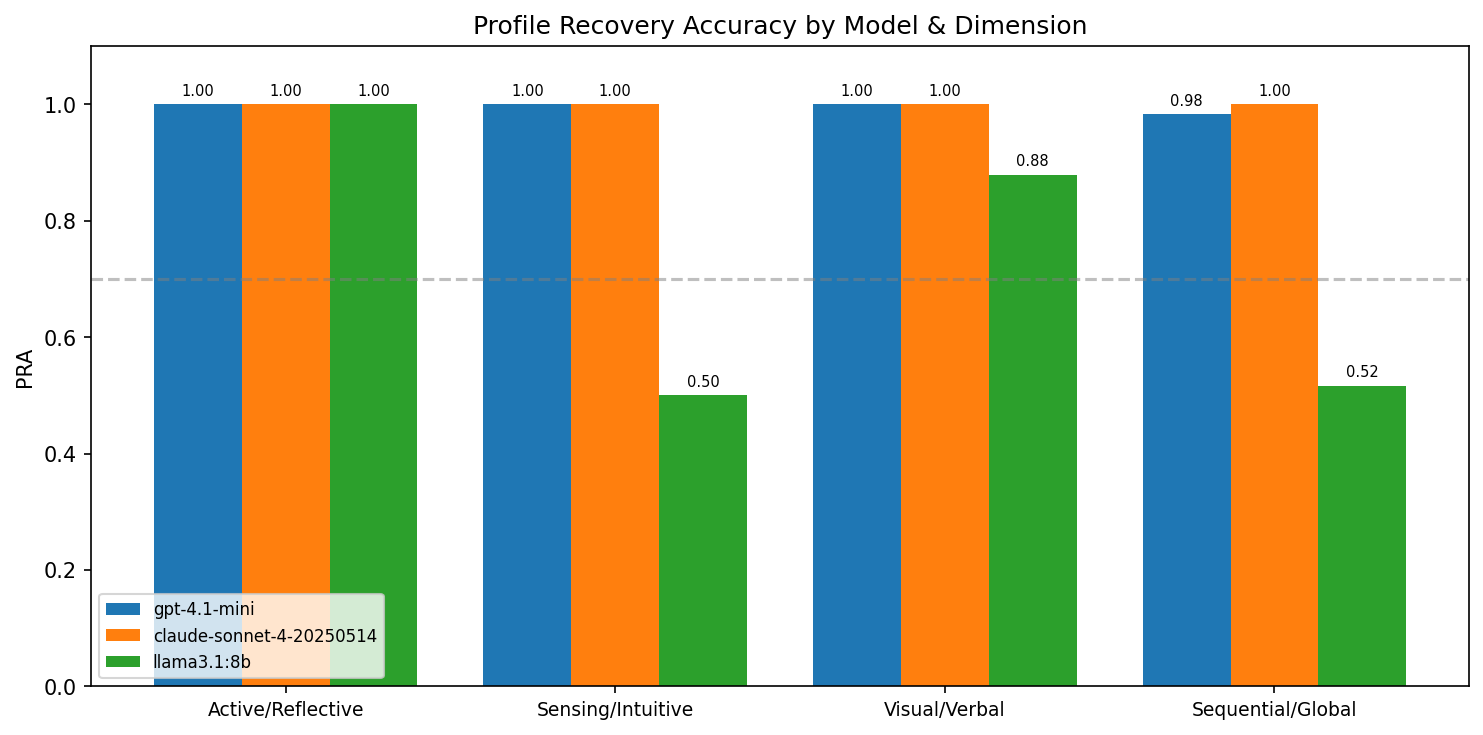

In [8]:
model_comparison_bar(df_pra)
display(Image(filename=str(FIGURES_DIR / "model_comparison_pra.png")))

### 3.2 Knowledge Level — PRA Comparison

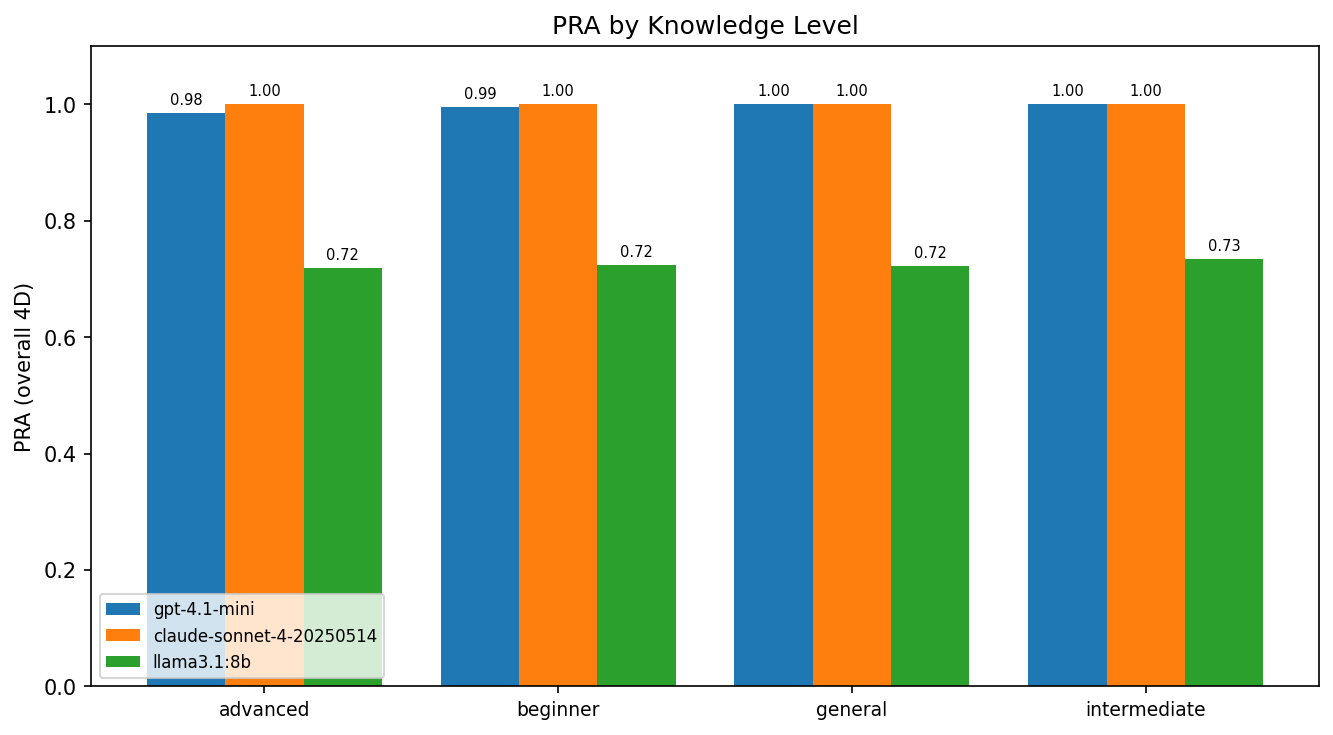

In [9]:
knowledge_level_comparison(df_pra)
display(Image(filename=str(FIGURES_DIR / "knowledge_level_pra.png")))

### 3.3 FSLSM vs Baseline — PRA

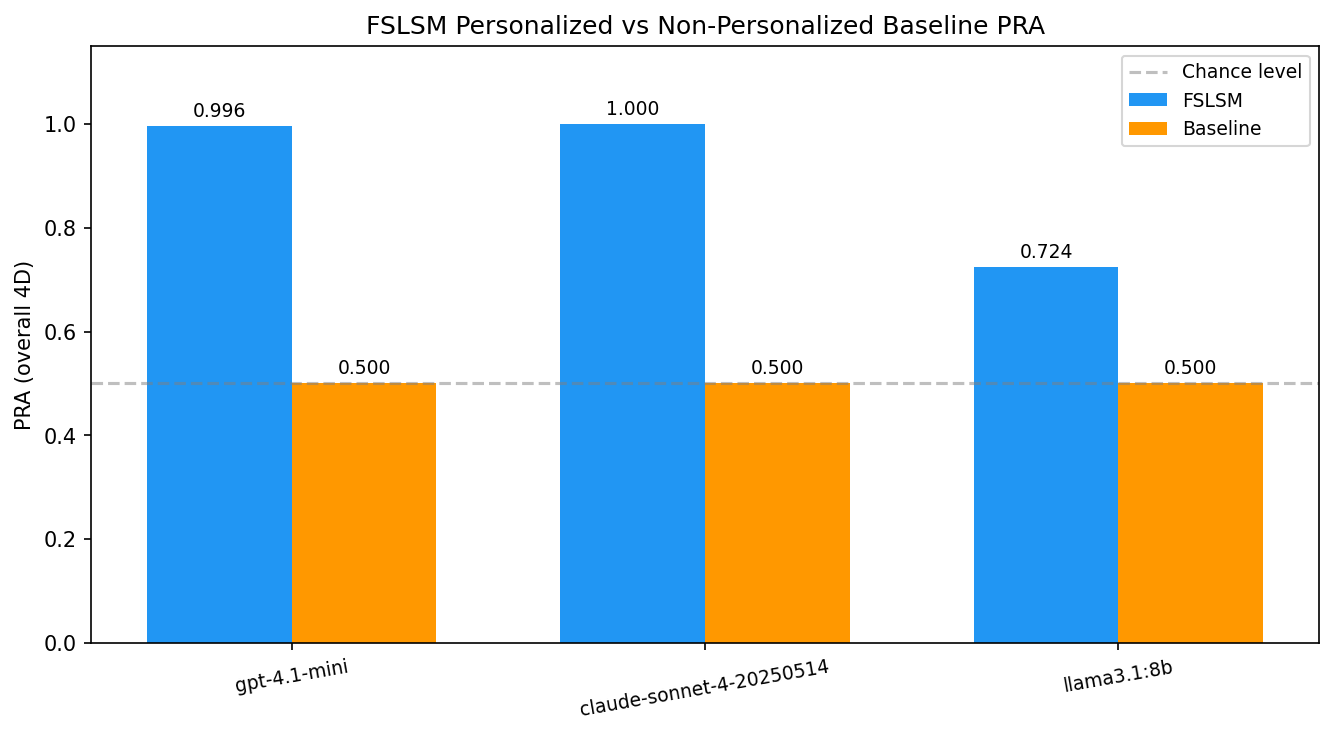

In [10]:
fslsm_vs_baseline_bar(df_pra)
display(Image(filename=str(FIGURES_DIR / "fslsm_vs_baseline_pra.png")))

### 3.4 DAS Comparison — Per Dimension (FSLSM)

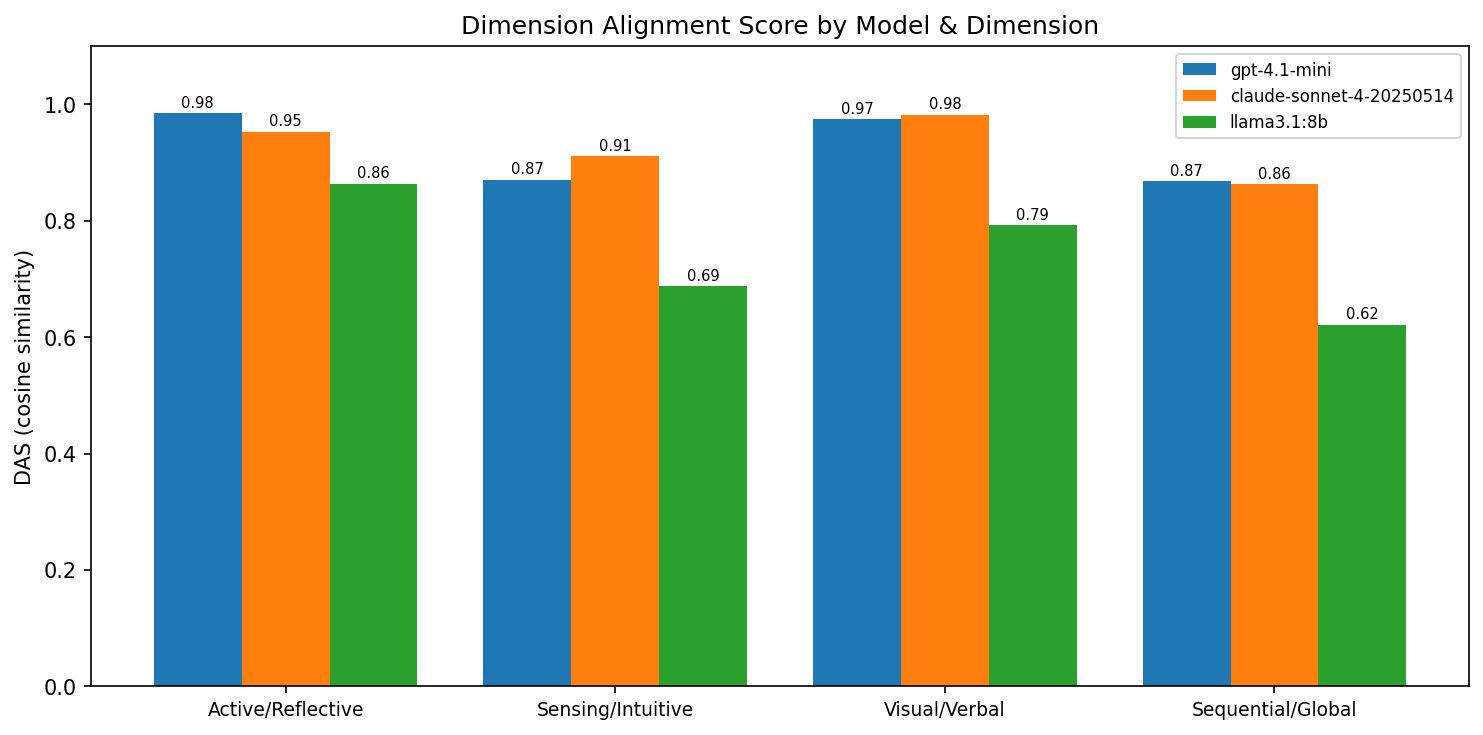

In [11]:
das_comparison_bar(df_das)
display(Image(filename=str(FIGURES_DIR / "das_comparison_bar.png")))

### 3.5 DAS — FSLSM vs Baseline

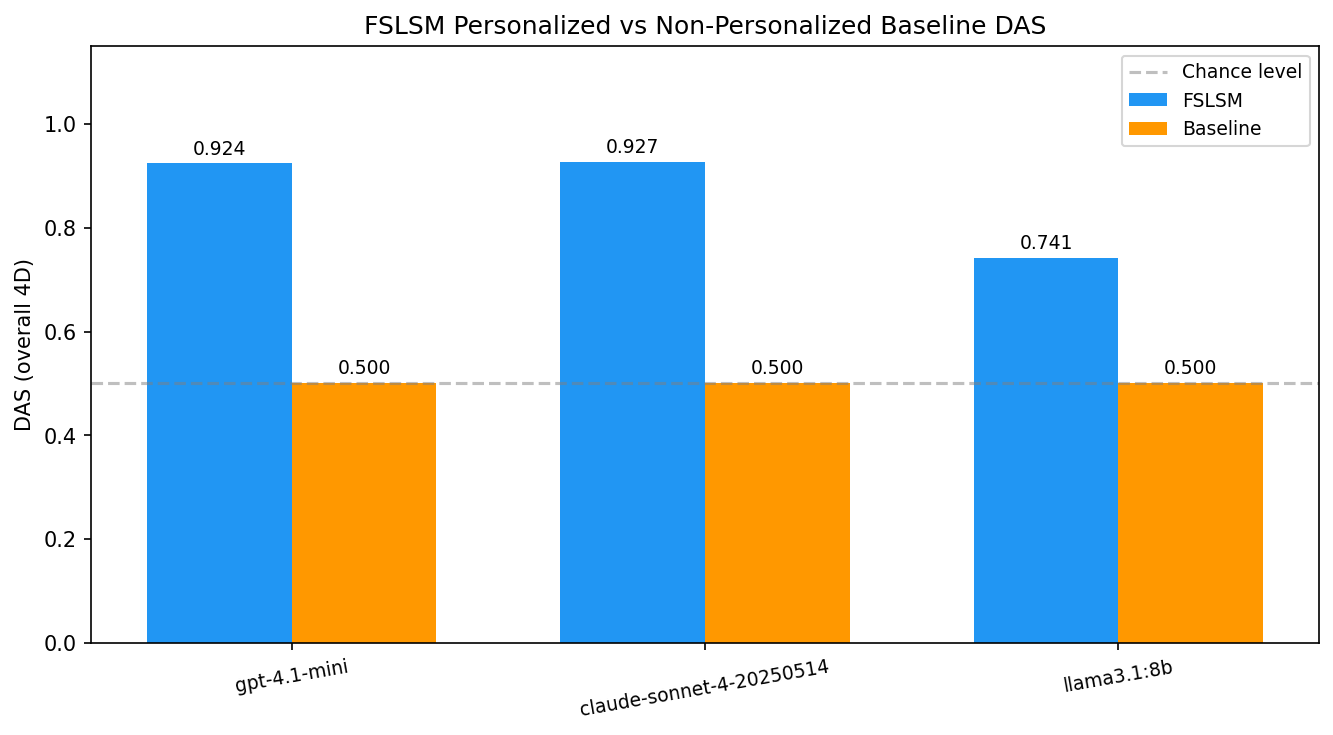

In [12]:
das_fslsm_vs_baseline_bar(df_das)
display(Image(filename=str(FIGURES_DIR / "das_fslsm_vs_baseline.png")))

### 3.6 FSLSM Profile Heatmaps (Raw Scores per Model)

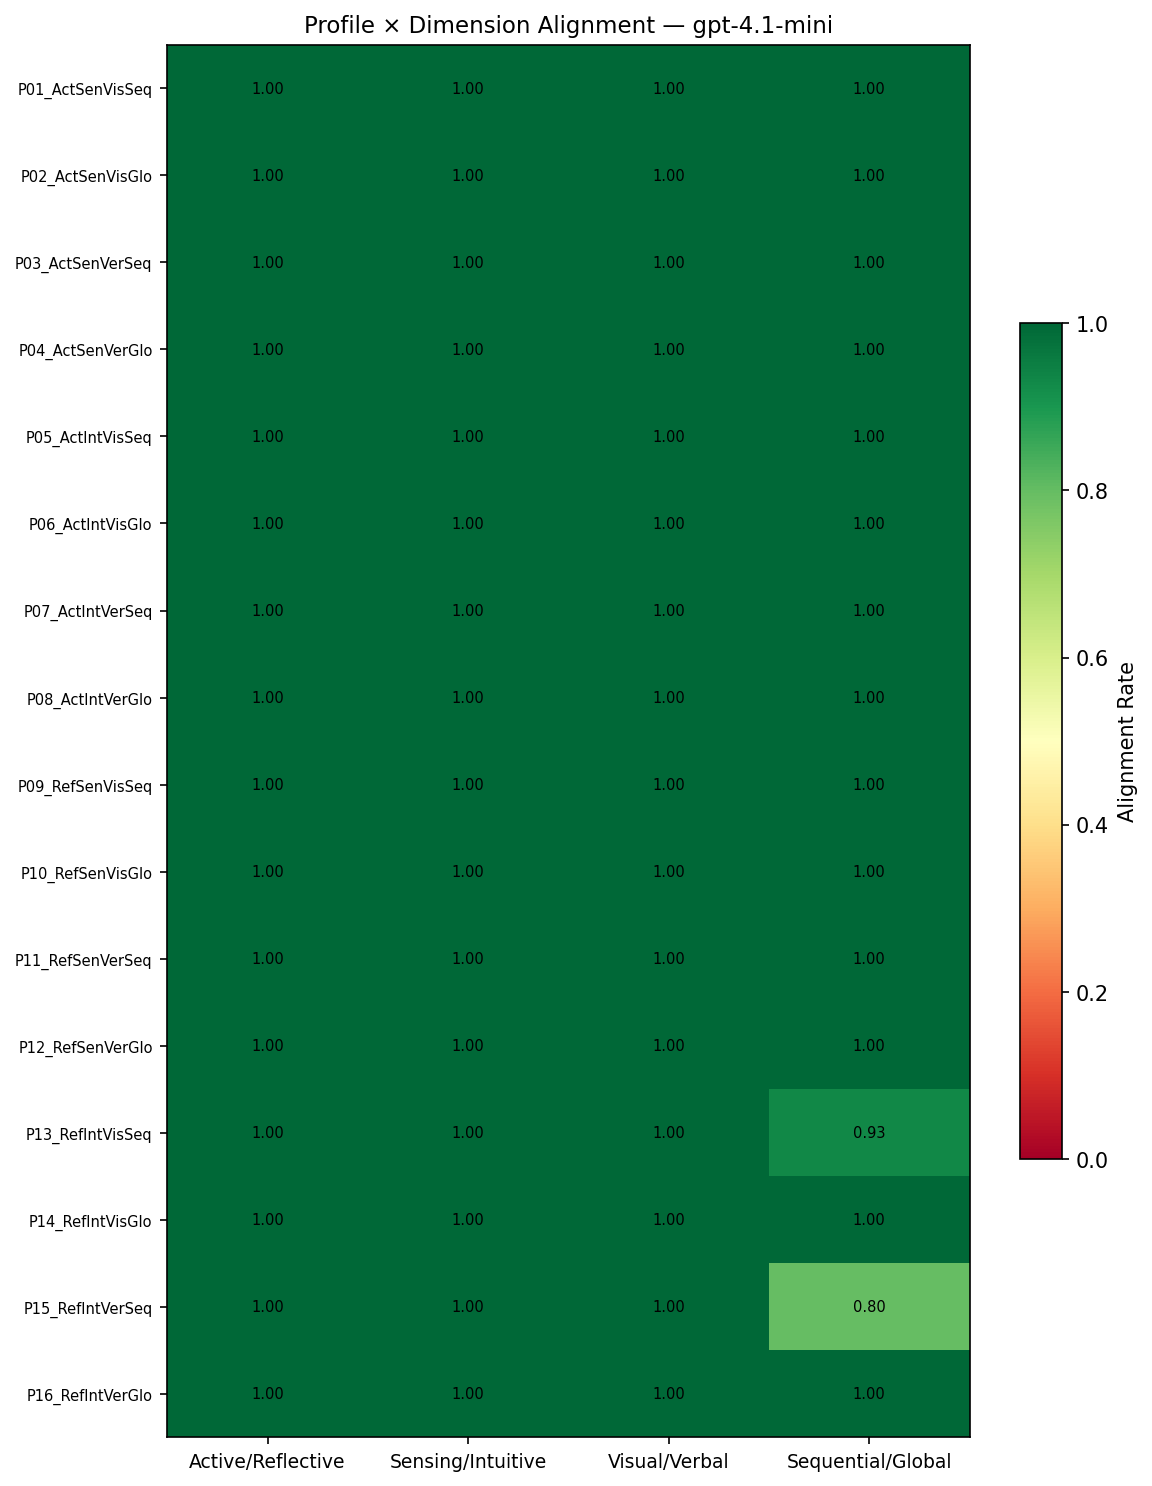

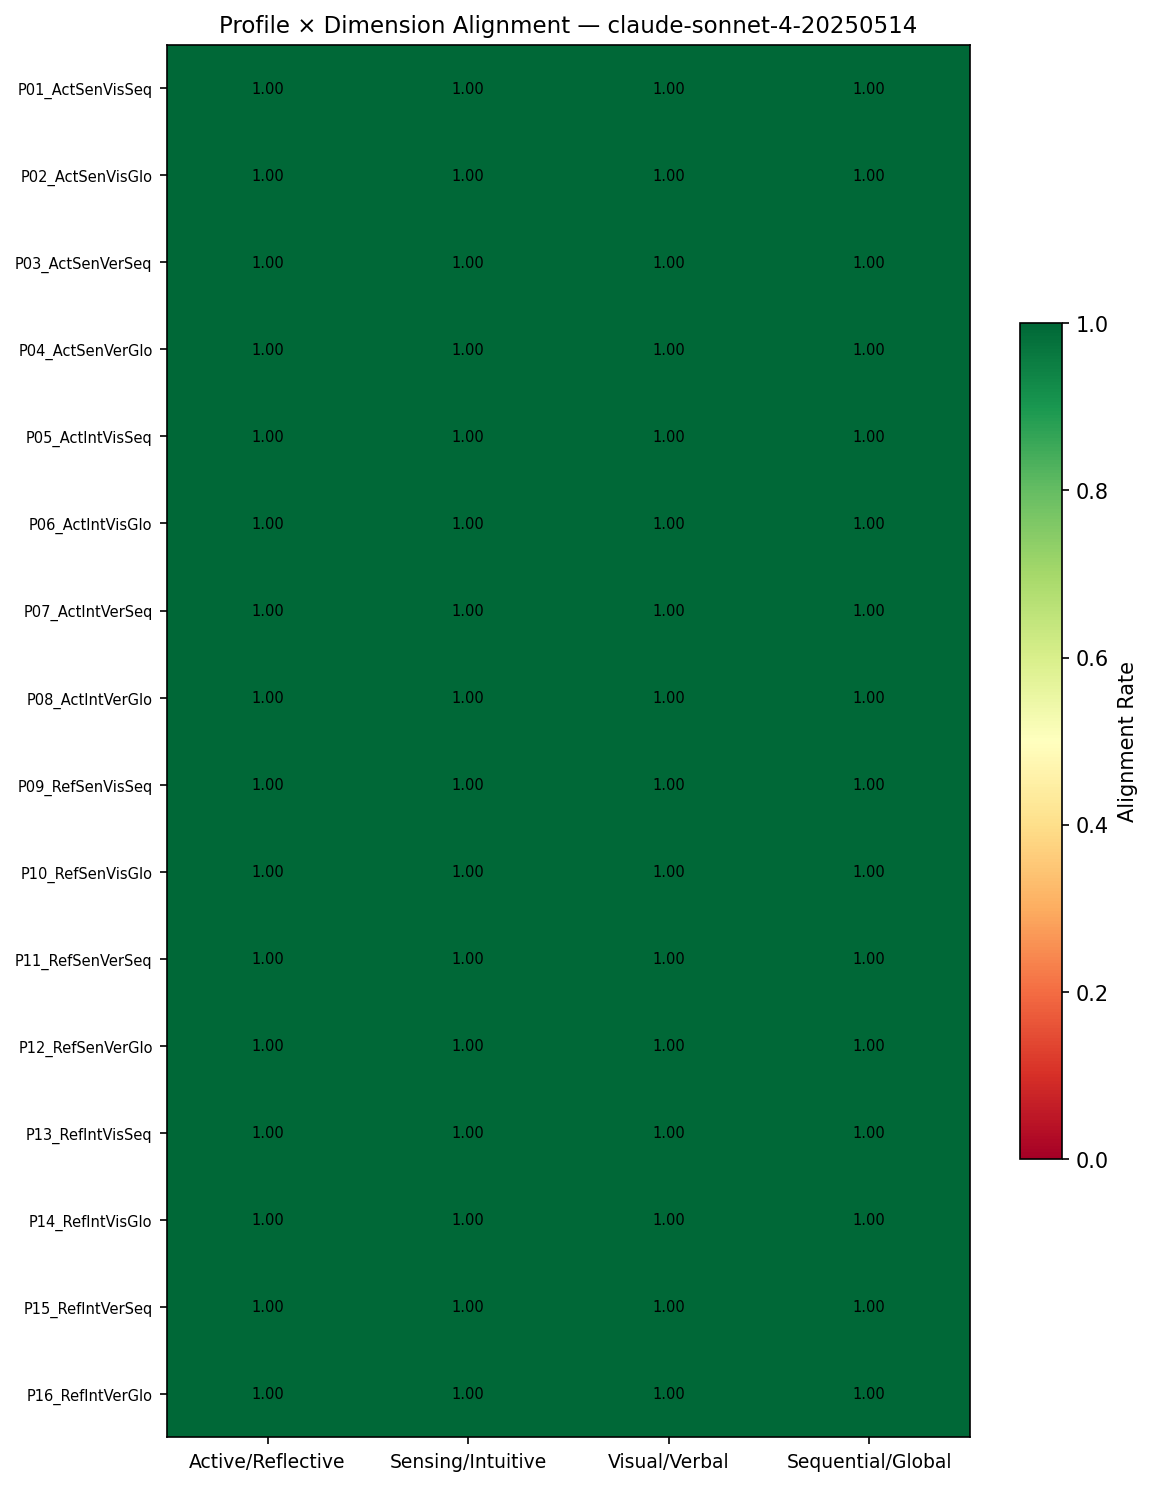

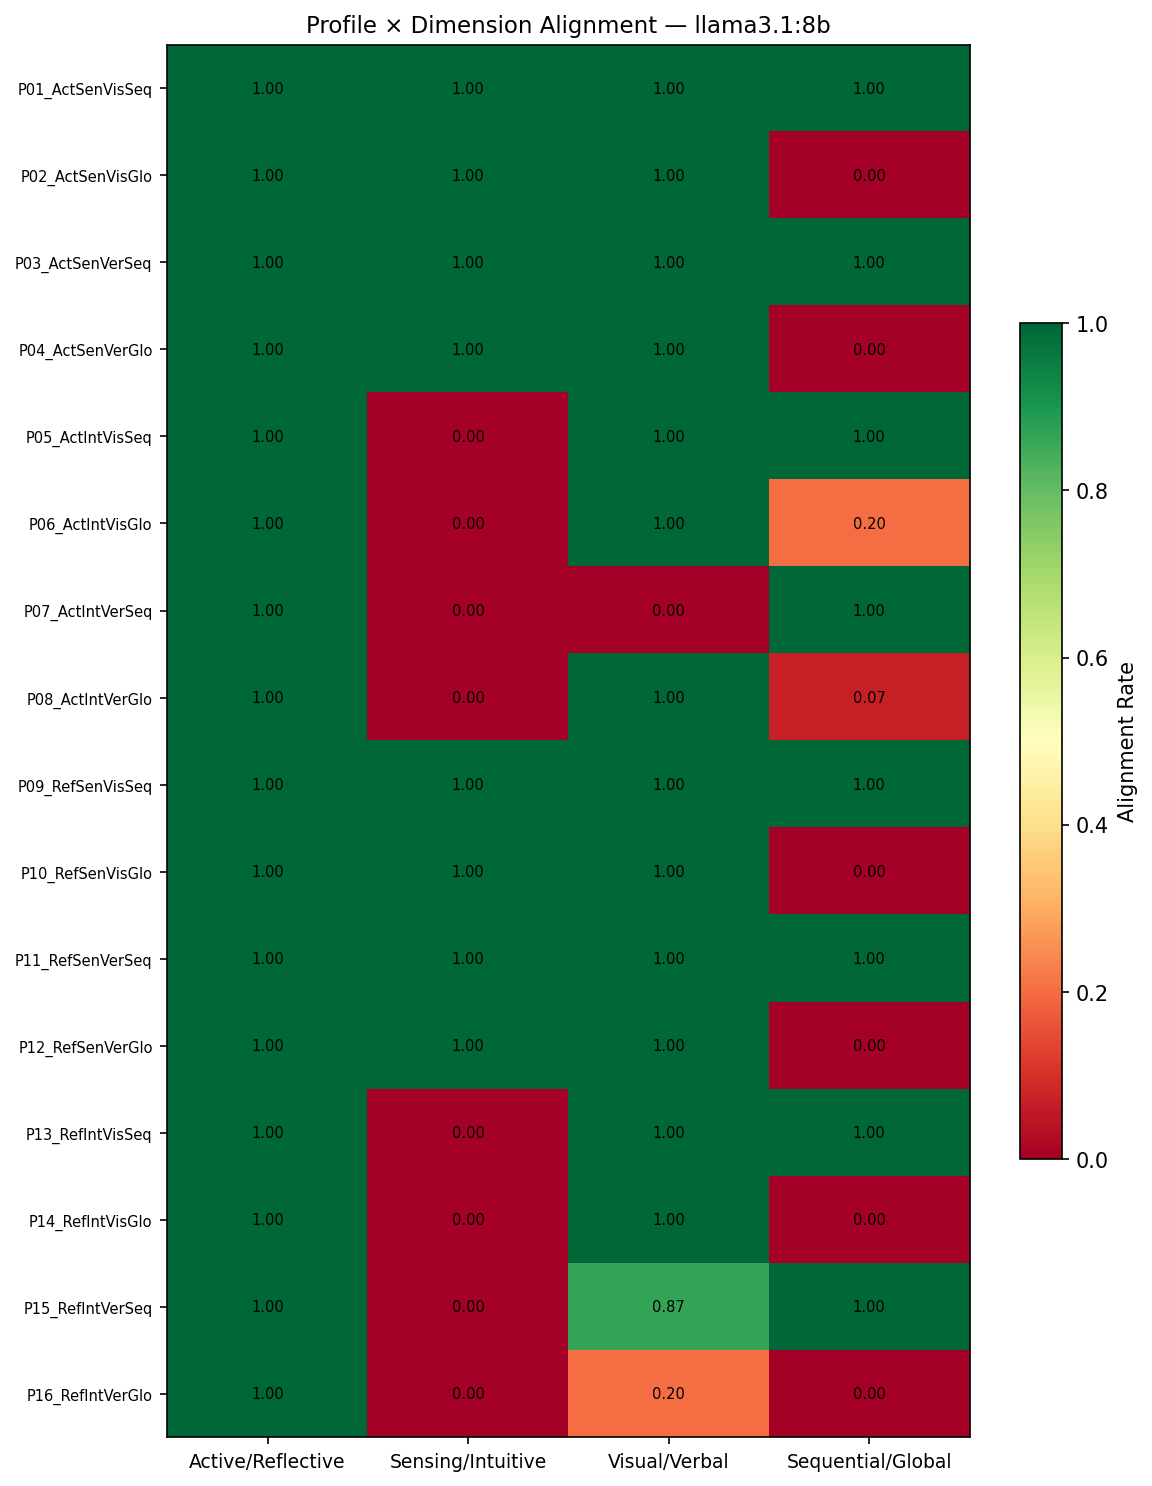

In [13]:
for model in MODELS:
    safe = model.replace("/", "_").replace(":", "_")
    results_file = METRICS_DIR / f"{safe}_results.json"
    if results_file.exists():
        results = json.loads(results_file.read_text())
        heatmap_profiles(results, model)
        fig_name = f"heatmap_{safe}.png"
        display(Image(filename=str(FIGURES_DIR / fig_name)))
    else:
        print(f"Skipping {model} — results file not found")

### 3.7 Baseline Heatmaps (Raw Scores per Model)

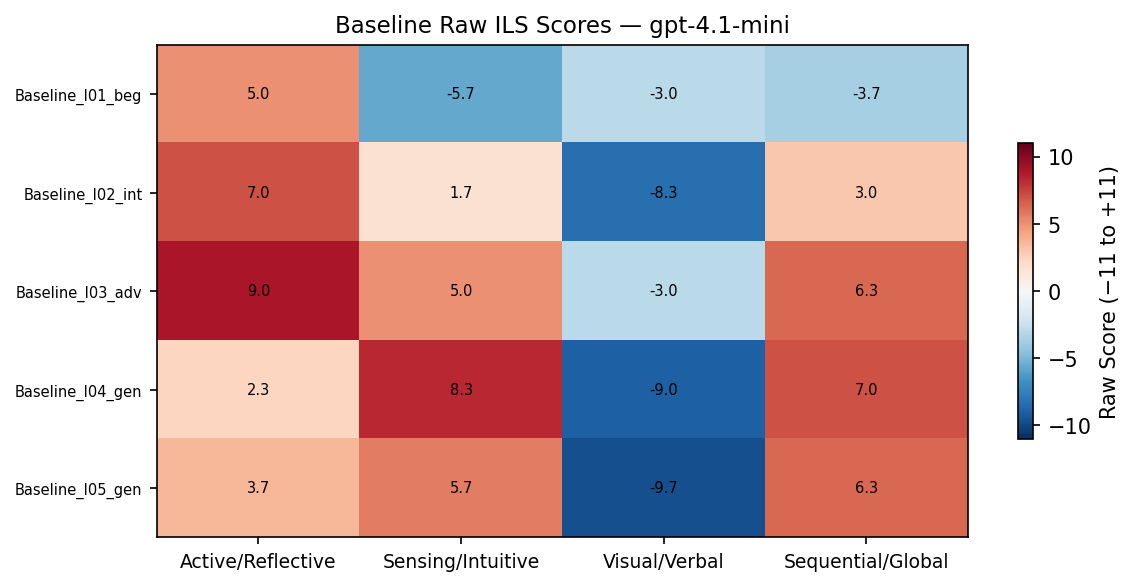

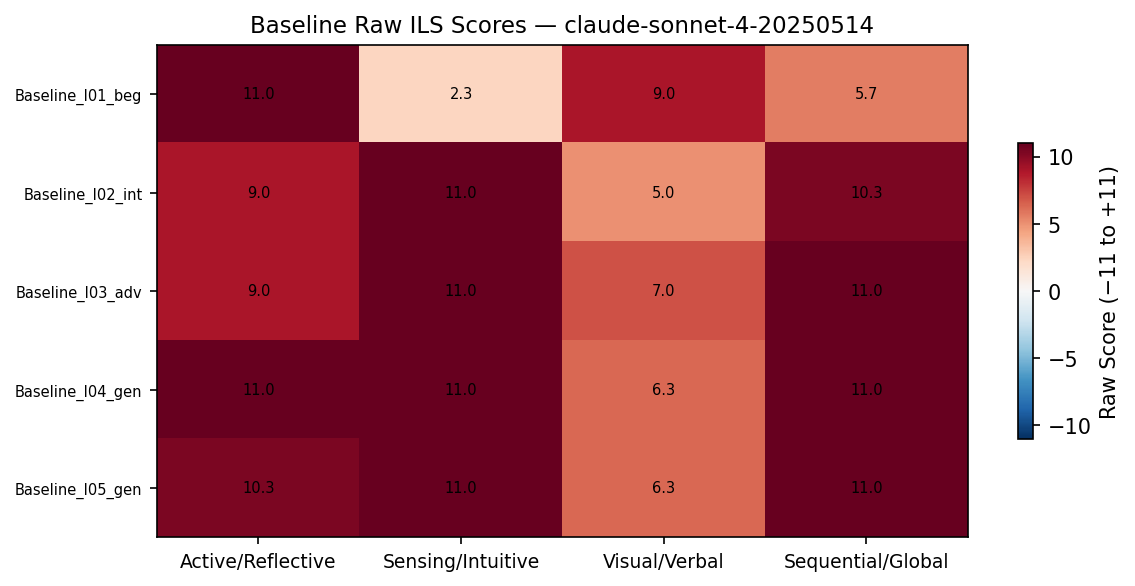

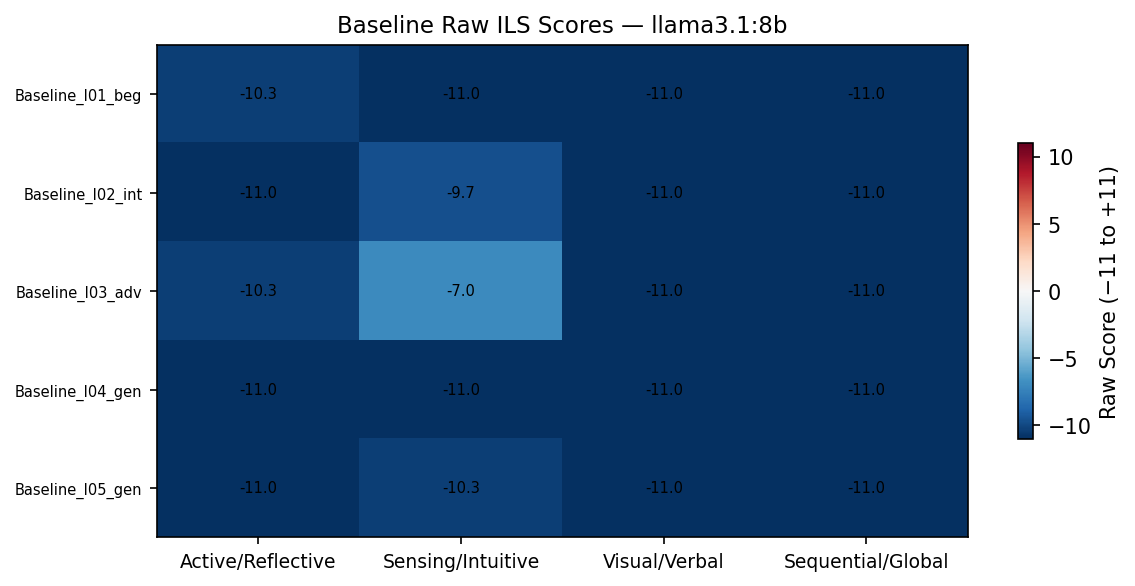

In [14]:
for model in MODELS:
    safe = model.replace("/", "_").replace(":", "_")
    bl_file = METRICS_DIR / f"{safe}_baseline_results.json"
    if bl_file.exists():
        bl_results = json.loads(bl_file.read_text())
        heatmap_baseline_bias(bl_results, model)
        fig_name = f"heatmap_baseline_{safe}.png"
        display(Image(filename=str(FIGURES_DIR / fig_name)))
    else:
        print(f"Skipping baseline {model} — file not found")

### 3.8 Baseline Bias Radar

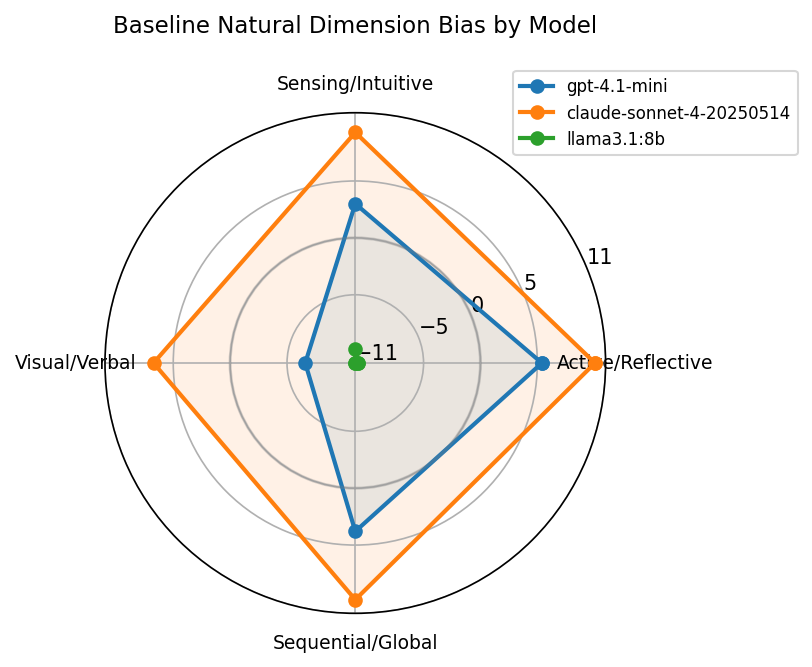

In [15]:
baseline_bias_radar(df_baseline)
display(Image(filename=str(FIGURES_DIR / "baseline_bias_radar.png")))

## 4. Baseline Analysis

In [16]:
# Baseline natural bias report
df_baseline.style.format({
    "avg_pra_vs_all": "{:.3f}",
    "std_pra_vs_all": "{:.3f}",
    "best_match_pra": "{:.3f}",
    "bias_act_ref_score": "{:.1f}",
    "bias_sen_int_score": "{:.1f}",
    "bias_vis_ver_score": "{:.1f}",
    "bias_seq_glo_score": "{:.1f}",
}).set_caption("Baseline Natural Bias per Model")

,model,avg_pra_vs_all,std_pra_vs_all,best_match_profile,best_match_pra,bias_act_ref,bias_sen_int,bias_vis_ver,bias_seq_glo,bias_act_ref_score,bias_sen_int_score,bias_vis_ver_score,bias_seq_glo_score
0,gpt-4.1-mini,0.500,0.206,P14_RefIntVisGlo,0.900,Reflective,Intuitive,Visual,Global,5.4,3.0,-6.6,3.8
1,claude-sonnet-4-20250514,0.500,0.250,P16_RefIntVerGlo,1.000,Reflective,Intuitive,Verbal,Global,10.1,9.3,6.7,9.8
2,llama3.1:8b,0.500,0.250,P01_ActSenVisSeq,1.000,Active,Sensing,Visual,Sequential,-10.7,-9.8,-11.0,-11.0


## 5. Cost Summary

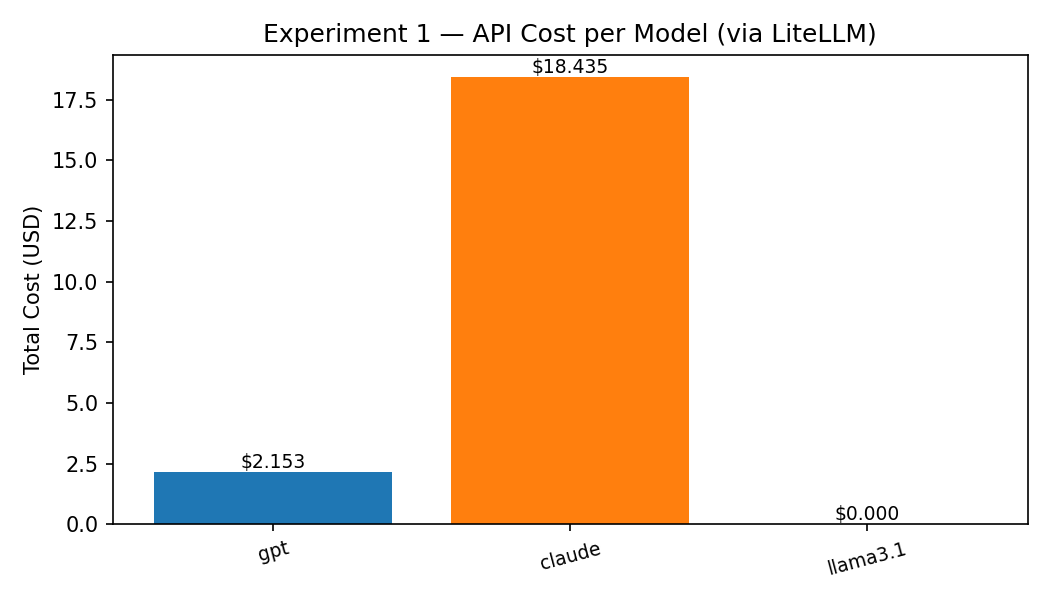

,model,condition,total_usd,mean_per_agent_trial_usd,num_records
0,gpt-4.1-mini,FSLSM,$2.0891,$0.008704,240
1,gpt-4.1-mini,Baseline,$0.0644,$0.004294,15
2,claude-sonnet-4-20250514,FSLSM,$17.8811,$0.074505,240
3,claude-sonnet-4-20250514,Baseline,$0.5534,$0.036895,15
4,llama3.1:8b,FSLSM,$0.0000,$0.000000,240
5,llama3.1:8b,Baseline,$0.0000,$0.000000,15


In [17]:
# Cost summary
cost_per_model_bar(df_cost)
display(Image(filename=str(FIGURES_DIR / "cost_per_model.png")))
df_cost.style.format({
    "total_usd": "${:.4f}",
    "mean_per_agent_trial_usd": "${:.6f}",
}).set_caption("Cost Summary")

## 6. Key Findings

1. **GPT-4.1-mini and Claude Sonnet achieve near-perfect PRA** (≥0.95), confirming that commercial LLMs faithfully encode FSLSM profiles via system-prompt persona instructions.

2. **Llama 3.1:8b shows lower fidelity** (~0.74 PRA), indicating that smaller open-source models struggle to maintain consistent learning-style personas across 44 ILS questions.

3. **DAS corroborates PRA**: GPT and Claude score >0.92 DAS, while Llama scores ~0.74. Baseline DAS is exactly 0.500 by symmetry, confirming that high FSLSM DAS is due to persona encoding, not model bias.

4. **Baseline agents show no systematic FSLSM alignment** (PRA ≈ 0.50, DAS = 0.50), proving that elevated PRA/DAS in FSLSM agents is caused by the persona encoding, not inherent model tendencies.

5. **Knowledge level has minimal impact** on PRA for GPT and Claude, but slightly affects Llama, suggesting that domain knowledge framing interacts with persona fidelity in smaller models.

6. **Cost**: GPT-4.1-mini is the most cost-effective commercial option; Llama runs locally at zero API cost but with reduced fidelity.